# 실험③ — abstention 은 임계값으로 못 고친다. 그럼 무엇으로 고치나

실험②의 결론은 여기서 멈춰 있다.

> 측정한 90여 개 설정 **전부** 보류여유가 음수였다. 최선이 −0.017.
> 임베딩은 "주제가 비슷한가"를 재지, "답이 있는가"를 재지 않는다.

이 노트북은 그 다음을 잰다. 재순위화 / 하이브리드 검색(BM25) / LLM 판정 중 무엇이
실제로 효과가 있는가.

---

## Phase 0 — 먼저, 우리가 어디 있는지

**기법을 고르기 전에 확인할 게 있다.** 실험②는 *"전부 음수"* 라고만 말한다.
그런데 보류여유는 이렇게 생겼다.

```
보류여유 = min(정답 있는 질문의 정답 점수) − max(정답 없는 질문의 최고점)
```

**극단값 두 개가 부호를 결정한다.** 그리고 부호밖에 안 알려준다.

실험①에서 분리도(평균 차이)로 판정했다가 실험②에서 뒤집힌 적이 있다.
그때 배운 게 *"지표가 틀리면 결론도 틀린다"* 였는데, 보류여유도 같은 함정을 갖고 있다.

| | 지표 | 함정 |
|---|---|---|
| 실험① | 분리도 = 평균 − 평균 | 평균이라 **분포의 겹침**을 못 봄 |
| 실험② | 보류여유 = 최소 − 최대 | **극단값 두 개**가 전부를 결정, 부호만 나옴 |

그래서 임계값과 무관한 지표를 하나 더 놓고 시작한다.

```
보류AUC = P(답할 수 있는 질문의 점수 > 답이 없는 질문의 점수)
```

**보류여유 > 0 ⟺ 보류AUC = 1.0** 이다.
즉 실험②의 "전부 음수"는 사실 **"전부 AUC < 1"** 이라는 말이고,
0.6인지 0.98인지는 아무도 모른다. **그 둘은 완전히 다른 상황이다.**

In [1]:
import json, os, time
from pathlib import Path

import httpx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from google import genai

import sweep_lib as S

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.width", 200)

load_dotenv(Path("../backend/.env"))
GEMINI_API_KEY = os.environ["GEMINI_API_KEY"]
GITHUB_TOKEN, GITHUB_REPO = os.environ["GITHUB_TOKEN"], os.environ["GITHUB_REPO"]

client = genai.Client(api_key=GEMINI_API_KEY)
MODEL = "gemini-embedding-001"

print("캐시 로드:", S.load_cache(), "건")

캐시 로드: 2197 건


In [2]:
# --- 볼트 노트 + 질문 로드 (실험②와 동일한 절차) ---
def fetch_notes():
    h = {"Authorization": f"Bearer {GITHUB_TOKEN}"}
    hr = {**h, "Accept": "application/vnd.github.raw"}
    out = {}
    with httpx.Client(timeout=60) as c:
        for folder in ("articles", "concepts", "projects"):
            r = c.get(f"https://api.github.com/repos/{GITHUB_REPO}/contents/{folder}", headers=h)
            if r.status_code == 404:
                continue
            r.raise_for_status()
            for f in r.json():
                if f["name"].endswith(".md"):
                    rr = c.get(f"https://api.github.com/repos/{GITHUB_REPO}/contents/{f['path']}", headers=hr)
                    rr.raise_for_status()
                    out[f["path"]] = rr.text
    return out

# ★ 실험② 이후 볼트에 들어간 노트는 제외한다.
#   저장 파이프라인을 검증하려고 만든 테스트 노트라 지식 노트가 아니고,
#   포함하면 실험②의 베이스라인과 비교가 안 된다.
EXCLUDE = ("Ingest-Pipeline",)

raw = fetch_notes()
dropped = [p for p in raw if any(x in p for x in EXCLUDE)]
for p in dropped:
    del raw[p]

note_paths = sorted(raw)
notes = [S.parse_note(raw[p], p) for p in note_paths]
path_to_idx = {p: i for i, p in enumerate(note_paths)}

pairs = [json.loads(l) for l in Path("data/pairs.jsonl").read_text(encoding="utf-8").splitlines() if l.strip()]
questions     = [p["question"] for p in pairs]
kinds         = [p["kind"] for p in pairs]
relevant_idx  = [[path_to_idx[x] for x in p["relevant_paths"] if x in path_to_idx] for p in pairs]

print(f"노트 {len(notes)}개 (제외 {len(dropped)}개: {dropped})")
print(f"질문 {len(questions)}개 · 정답 없는 질문 {sum(1 for r in relevant_idx if not r)}개")

노트 21개 (제외 1개: ['projects/2026-09-02-mdragchatbot-Ingest-Pipeline-검증-테스트.md'])
질문 22개 · 정답 없는 질문 3개


### 현재 코드와 똑같은 설정으로 재현

실험②가 채택한 설정이다 — **요약을 임베딩**하고, 문서는 `RETRIEVAL_DOCUMENT`,
질문은 `RETRIEVAL_QUERY`. 캐시에 이미 있으므로 **API 호출 0회**.

In [3]:
rep = "요약"
doc_texts, owner = S.build_units(notes, rep)

t0 = time.time()
doc_emb = S.embed_cached(client, MODEL, doc_texts, task_type="RETRIEVAL_DOCUMENT")
q_emb   = S.embed_cached(client, MODEL, questions,  task_type="RETRIEVAL_QUERY")
print(f"임베딩 {time.time()-t0:.1f}초 · 캐시 {S.save_cache()}건")

sim = S.aggregate(S.cosine_matrix(q_emb, doc_emb), owner, len(notes))
base = S.evaluate(sim, relevant_idx, kinds)

print("\n=== 현재 코드 설정 (요약 / DOCUMENT-QUERY / 3072) ===")
for k, v in base.items():
    print(f"  {k:12s} {v:.4f}")

임베딩 0.0초 · 캐시 2197건

=== 현재 코드 설정 (요약 / DOCUMENT-QUERY / 3072) ===
  AUC          0.9811
  분리도          0.1228
  R@1          0.9474
  R@3          1.0000
  R@5          1.0000
  MRR          0.9737
  최적임계값        0.6447
  F1           0.5263
  보류여유         -0.0256
  보류AUC        0.9474
  보류AUC엄격      0.9474
  정답없음최고       0.6703
  관련최저         0.6447


### 핵심 — 보류AUC 는 얼마인가

이 숫자 하나가 다음 단계를 정한다.

| 보류AUC | 상황 | 다음 |
|---|---|---|
| ≥ 0.95 | 거의 다 왔다 | 리랭커·BM25 로 밀어붙일 값어치 있음 |
| 0.7 ~ 0.9 | 애매 | 세 기법 다 재봐야 함 |
| ≤ 0.6 | 임베딩 계열로는 가망 없음 | **LLM 판정으로 직행** |

In [4]:
loose  = S.abstention_auc(sim, relevant_idx, strict=False)
strict = S.abstention_auc(sim, relevant_idx, strict=True)
margin, no_ans_hi, rel_lo = S.abstention_margin(sim, relevant_idx, kinds)

print("보류여유 (실험②의 지표)")
print(f"  {margin:+.4f}   = 관련최저 {rel_lo:.4f} − 정답없음최고 {no_ans_hi:.4f}")
print(f"  → 음수이므로 '임계값 하나로는 못 가른다'. 여기까지가 실험②가 알던 것.\n")

print("보류AUC (이번에 추가)")
print(f"  느슨 {loose:.4f}   답할지 말지를 가르는가")
print(f"  엄격 {strict:.4f}   정답으로 답할 수 있는지까지 가르는가")
print(f"\n  1.0 이면 임계값 하나로 완벽 분리 가능. 0.5 면 동전던지기.")

보류여유 (실험②의 지표)
  -0.0256   = 관련최저 0.6447 − 정답없음최고 0.6703
  → 음수이므로 '임계값 하나로는 못 가른다'. 여기까지가 실험②가 알던 것.

보류AUC (이번에 추가)
  느슨 0.9474   답할지 말지를 가르는가
  엄격 0.9474   정답으로 답할 수 있는지까지 가르는가

  1.0 이면 임계값 하나로 완벽 분리 가능. 0.5 면 동전던지기.


In [5]:
# 정답 없는 질문 3개가 각각 무엇에 걸렸나 — 실패의 실체
print("=== 답이 없는 질문이 무엇을 물어왔나 ===\n")
for qi, (q, rel) in enumerate(zip(questions, relevant_idx)):
    if rel:
        continue
    order = np.argsort(-sim[qi])[:3]
    print(f"Q: {q}")
    for rank, di in enumerate(order, 1):
        mark = " ← 0.65 통과" if sim[qi][di] >= 0.65 else ""
        print(f"   {rank}. {sim[qi][di]:.3f}  {notes[di]['title'][:45]}{mark}")
    print()

# 답이 있는 질문 중 가장 아슬아슬한 것
print("=== 답이 있는데 점수가 낮은 질문 (놓칠 위험) ===\n")
rows = []
for qi, (q, rel) in enumerate(zip(questions, relevant_idx)):
    if not rel:
        continue
    rows.append((max(sim[qi][d] for d in rel), sim[qi].max(), q))
for best_rel, top1, q in sorted(rows)[:5]:
    print(f"  정답최고 {best_rel:.3f} / 전체1위 {top1:.3f}  {q[:55]}")

=== 답이 없는 질문이 무엇을 물어왔나 ===

Q: LLM-as-a-judge로 평가 파이프라인 설계하려면? 골든 데이터셋은 어떻게 만들어?
   1. 0.670  LLM 핵심 용어 및 아키텍처 설계 가이드 ← 0.65 통과
   2. 0.663  AX 엔지니어 실무 기술 스택 ← 0.65 통과
   3. 0.648  AI 하네스 엔지니어링 자동화: 메타-하네스

Q: vLLM으로 서빙하면서 LoRA 파인튜닝하려면 PyTorch 설정을 어떻게 잡아?
   1. 0.636  AX 엔지니어 실무 기술 스택
   2. 0.630  LLM 핵심 용어 및 아키텍처 설계 가이드
   3. 0.626  백엔드 기술 스택 및 실무 판단 규칙 정리

Q: BM25랑 하이브리드 검색 붙이고 리랭커까지 태우려면 어떻게 해?
   1. 0.644  AX 엔지니어 실무 기술 스택
   2. 0.625  백엔드 기술 스택 및 실무 판단 규칙 정리
   3. 0.623  Python 핵심 라이브러리 및 기술 스택 정리

=== 답이 있는데 점수가 낮은 질문 (놓칠 위험) ===

  정답최고 0.647 / 전체1위 0.647  MSA랑 모놀리식 중에 뭘 골라야 하는지 기준이 뭐야?
  정답최고 0.650 / 전체1위 0.650  n8n이나 Make 같은 워크플로우 자동화 도구는 어디에 붙이는 거야?
  정답최고 0.669 / 전체1위 0.669  LangSmith나 Langfuse 같은 도구는 어디에 쓰는 거야?
  정답최고 0.685 / 전체1위 0.685  내가 만든 RAG 챗봇은 저장할 내용인지 질문인지 어떻게 구분해?
  정답최고 0.699 / 전체1위 0.699  SQL Injection이랑 XSS는 어떻게 막아?


### 의심 — 라벨이 틀린 건 아닐까?

0.670 을 받은 건 「LLM 핵심 용어 및 아키텍처 설계 가이드」다.
질문은 *"LLM-as-a-judge로 평가 파이프라인 설계하려면?"* 이고.
**저 노트에 실제로 그 내용이 있다면 라벨이 틀린 것이지 검색이 틀린 게 아니다.**

실험①에서 무관최고 0.746 을 "제목이 비슷한 유사 노트 탓"이라고 예측했다가
상위 10개에 유사 노트가 하나도 없어서 틀린 적이 있다. **같은 검사를 여기서도 한다.**

In [6]:
# 질문의 핵심 용어가 그 노트에 문자열로 존재하는가 — 결정론적 확인
import re

suspect_path = [p for p in note_paths if "LLM-핵심-용어" in p][0]
body = raw[suspect_path]

TERMS = ["LLM-as-a-judge", "as-a-judge", "골든", "golden", "평가", "eval", "데이터셋",
         "BM25", "리랭", "rerank", "vLLM", "LoRA", "파인튜닝"]

print(f"{suspect_path}  ({len(body)}자)\n")
hits = {t: len(re.findall(re.escape(t), body, re.I)) for t in TERMS}
for t, n in hits.items():
    print(f"  {'○' if n else '·'} {t:16s} {n}회")

total = sum(hits.values())
print(f"\n→ 핵심 용어 {total}회 등장.")
print("   0 이면 라벨이 맞다 — 답이 없는 게 맞고, 임베딩이 주제만 보고 끌려온 것이다.")

concepts/2026-04-10-LLM-핵심-용어-및-아키텍처-설계-가이드.md  (2264자)

  · LLM-as-a-judge   0회
  · as-a-judge       0회
  · 골든               0회
  · golden           0회
  · 평가               0회
  · eval             0회
  · 데이터셋             0회
  · BM25             0회
  · 리랭               0회
  · rerank           0회
  · vLLM             0회
  · LoRA             0회
  · 파인튜닝             0회

→ 핵심 용어 0회 등장.
   0 이면 라벨이 맞다 — 답이 없는 게 맞고, 임베딩이 주제만 보고 끌려온 것이다.


**의심은 틀렸다.** 핵심 용어가 **0회**다. 2,264자짜리 노트에 `LLM-as-a-judge`도
`골든 데이터셋`도 `평가`도 없다. 라벨은 맞았고, **0.670 은 진짜 오답이다.**

실험②의 진단이 정확했던 셈이다 — 임베딩은 `LLM` · `아키텍처` · `설계` 라는
**주제**를 보고 끌려왔지, 답이 적혀 있는지를 본 게 아니다.

그리고 이건 **BM25 가 잡을 수 있는 형태의 실패**다.
질문의 핵심 용어가 노트에 문자열로 0회이므로, 어휘 겹침으로 재면 0점이어야 한다.
Phase 2 의 첫 가설이 여기서 나온다.

답 없음 표본이 3개뿐이다. 이 히스토그램은 막대 3개로 그려진 것이고,
보류여유는 그중 '최댓값 하나'가 결정한다. Phase 1 에서 이걸 늘려야 하는 이유.


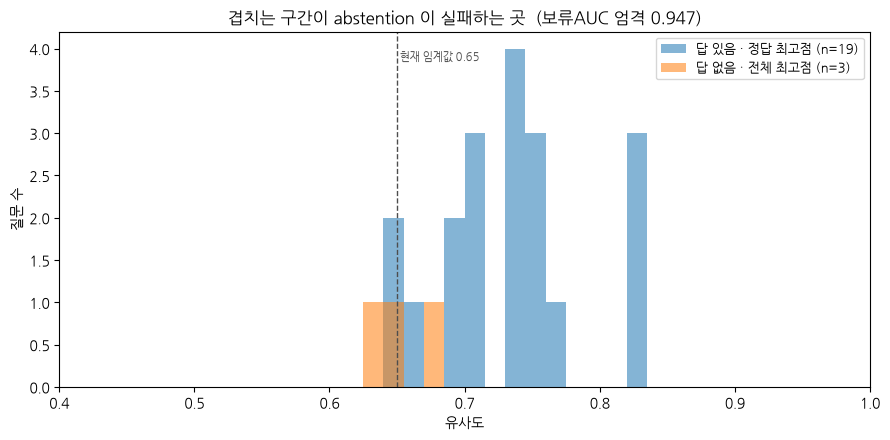

In [7]:
# 두 분포를 겹쳐 그린다 — 얼마나 겹치는지가 전부다
fig, ax = plt.subplots(figsize=(9, 4.5))
bins = np.linspace(0.4, 1.0, 41)

pos_loose  = np.array([sim[qi].max() for qi, r in enumerate(relevant_idx) if r])
pos_strict = np.array([max(sim[qi][d] for d in r) for qi, r in enumerate(relevant_idx) if r])
neg        = np.array([sim[qi].max() for qi, r in enumerate(relevant_idx) if not r])

ax.hist(pos_strict, bins=bins, alpha=.55, label=f"답 있음 · 정답 최고점 (n={len(pos_strict)})")
ax.hist(neg,        bins=bins, alpha=.55, label=f"답 없음 · 전체 최고점 (n={len(neg)})")
ax.axvline(0.65, color="0.3", ls="--", lw=1)
ax.text(0.652, ax.get_ylim()[1]*.92, "현재 임계값 0.65", fontsize=8, color="0.3")
ax.set_xlim(0.4, 1.0)
ax.set_xlabel("유사도"); ax.set_ylabel("질문 수")
ax.set_title(f"겹치는 구간이 abstention 이 실패하는 곳  (보류AUC 엄격 {strict:.3f})")
ax.legend(fontsize=9)
fig.tight_layout()

print(f"답 없음 표본이 {len(neg)}개뿐이다. 이 히스토그램은 막대 {len(neg)}개로 그려진 것이고,")
print("보류여유는 그중 '최댓값 하나'가 결정한다. Phase 1 에서 이걸 늘려야 하는 이유.")

In [8]:
# 결과 저장 — 나중에 기법별 결과와 나란히 놓기 위해
Path("results").mkdir(exist_ok=True)
row = {"단계": "Phase0 베이스라인", "기법": "임베딩 단독", "표현": rep,
       "노트수": len(notes), "질문수": len(questions),
       "정답없음수": int(sum(1 for r in relevant_idx if not r)), **base}
pd.DataFrame([row]).to_csv("results/03_abstention.csv", index=False)
print(pd.DataFrame([row]).T.to_string(header=False))

단계       Phase0 베이스라인
기법             임베딩 단독
표현                 요약
노트수                21
질문수                22
정답없음수               3
AUC          0.981053
분리도          0.122796
R@1          0.947368
R@3               1.0
R@5               1.0
MRR          0.973684
최적임계값        0.644704
F1           0.526316
보류여유        -0.025591
보류AUC        0.947368
보류AUC엄격      0.947368
정답없음최고       0.670295
관련최저         0.644704

## Phase 0 판단

| | 값 |
|---|---|
| 보류여유 (실험②의 지표) | **−0.0256** |
| **보류AUC** 느슨 / 엄격 | **0.947 / 0.947** |
| AUC · R@3 (회귀 감시) | 0.981 · 1.000 — 검색 자체는 문제없음 |

### 판정 — "가망 없음"이 아니었다

실험②의 *"90여 설정 전부 보류여유 음수"* 는 사실 **"전부 보류AUC < 1"** 이라는 말이었다.
그런데 실제 값은 **0.947** 이다. 가망 없는 0.6 대가 아니라 **거의 다 온 상태**다.

**실패가 한 질문에 몰려 있다.** 19×3 = 57 쌍 중 뒤집힌 건 **3쌍뿐**이고,
전부 같은 질문(`LLM-as-a-judge`, 0.670) 때문이다.

```
답 없는 질문 3개
  0.670  LLM-as-a-judge 평가 파이프라인   ← 이것 하나만 뚫림
  0.644  BM25 하이브리드 + 리랭커          이미 막힘
  0.636  vLLM 서빙 + LoRA                이미 막힘
```

나머지 둘은 현재 임계값(0.65)에서 **이미 정상 작동한다.**
지표 하나를 바꿨을 뿐인데 문제의 크기가 "전면 실패"에서 "한 군데 누수"로 바뀌었다.

> 실험①에서 분리도로 판정했다가 AUC 로 뒤집힌 것과 **같은 일이 또 일어났다.**
> 그때 배운 게 *"지표가 틀리면 결론도 틀린다"* 였는데, 그 교훈을 실험②의 지표에는
> 적용하지 않고 있었다.

### 라벨 검증 — 의심은 틀렸다

0.670 이 라벨 오류일 가능성을 검사했으나, 해당 노트에 핵심 용어가 **0회**였다.
**진짜 오답이 맞다.** 임베딩이 주제만 보고 끌려온 것이다.

### 아직 못 믿는 것

- **`n=3`.** 보류AUC 0.947 도 답 없는 질문 3개로 계산했다.
  하나만 달라도 0.63 이나 1.0 으로 튄다. **실험②가 3개에 의존했던 문제가 그대로 있다.**
- 노트가 **21개**다. 실험② 당시는 20개 — 데모를 찍으며 저장한 노트가 하나 늘었다.
  AUC 0.982 → 0.981 로 차이는 미미하지만 베이스라인이 완전히 같지는 않다.

### 다음 단계

**Phase 2 의 BM25 를 먼저 싸게 확인한다 (B → A).**

0.670 을 만든 노트에 질문의 핵심 용어가 0회라는 건, **어휘 겹침으로 재면 0점**이라는 뜻이다.
가설이 맞는지 30분이면 확인되고, 결과에 따라 Phase 1 에서 만들 질문의 성격이 달라진다.

- BM25 가 통하면 → *"어휘는 안 겹치는데 주제는 같은"* 질문을 집중적으로 만든다
- 안 통하면 → 가설을 접고 리랭커·LLM 판정 쪽을 본다

그 다음 Phase 1(정답없음 질문 25개로 확장)으로 돌아온다.